In [ ]:
# ============================================================
# Sign Language MNIST — Step 1: Get the dataset into Colab
# ============================================================

In [ ]:
# ---- Cell 1: install kaggle API ----
!pip install kaggle -q


In [ ]:
# ---- Cell 2 (revised): enter Kaggle username + key directly, no file needed ----
import os, json
from getpass import getpass


In [ ]:
#Cell 2A
kaggle_username = input("Enter your Kaggle username: ")
kaggle_key = getpass("Enter your Kaggle API key (hidden input): ")


Enter your Kaggle username: TEHGN12
Enter your Kaggle API key (hidden input): ··········


In [ ]:
#Cell 2B
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({"username": kaggle_username, "key": kaggle_key}, f)

In [ ]:
#Cell 2C
os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("kaggle.json created.")

kaggle.json created.


In [ ]:
# ---- Cell 3: download the dataset ----
!kaggle datasets download -d datamunge/sign-language-mnist
!unzip -q sign-language-mnist.zip -d sign_mnist_data
!ls sign_mnist_data

Dataset URL: https://www.kaggle.com/datasets/datamunge/sign-language-mnist
License(s): CC0-1.0
100% 62.6M/62.6M [00:00<00:00, 125MB/s]

american_sign_language.PNG  sign_mnist_test	 sign_mnist_train.csv
amer_sign2.png		    sign_mnist_test.csv
amer_sign3.png		    sign_mnist_train


In [ ]:
# ============================================================
# Sign Language MNIST — Step 2: Detailed Dataset Inspection
# ============================================================


In [ ]:
# ---- Cell 4: imports ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
# ---- Cell 5: load data ----
train_df = pd.read_csv("sign_mnist_data/sign_mnist_train.csv")
test_df = pd.read_csv("sign_mnist_data/sign_mnist_test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (27455, 785)
Test shape: (7172, 785)


In [ ]:
# ---- Cell 6: basic structure ----
print(train_df.info())
print("\nColumns preview:", train_df.columns[:5].tolist(), "...", train_df.columns[-3:].tolist())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27455 entries, 0 to 27454
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 164.4 MB
None

Columns preview: ['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4'] ... ['pixel782', 'pixel783', 'pixel784']


In [ ]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [ ]:
# ---- Cell 7: missing values / duplicates ----
print("Missing values in train:", train_df.isnull().sum().sum())
print("Missing values in test:", test_df.isnull().sum().sum())


Missing values in train: 0
Missing values in test: 0


In [ ]:
print("Duplicate rows in train:", train_df.duplicated().sum())
print("Duplicate rows in test:", test_df.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test: 0


In [ ]:
# ---- Cell 8: label distribution ----
print("Unique labels in train:", sorted(train_df["label"].unique()))


Unique labels in train: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


In [ ]:
print("Number of classes:", train_df["label"].nunique())

Number of classes: 24


In [ ]:
# Note: labels are 0-25 mapping to A-Z, but J(9) and Z(25) are EXCLUDED
# since they require motion — this dataset is static images only.
# Confirm this:
missing_labels = set(range(26)) - set(train_df["label"].unique())
print("Label values NOT present (should be {9, 25} = J, Z):", missing_labels)

Label values NOT present (should be {9, 25} = J, Z): {9, 25}


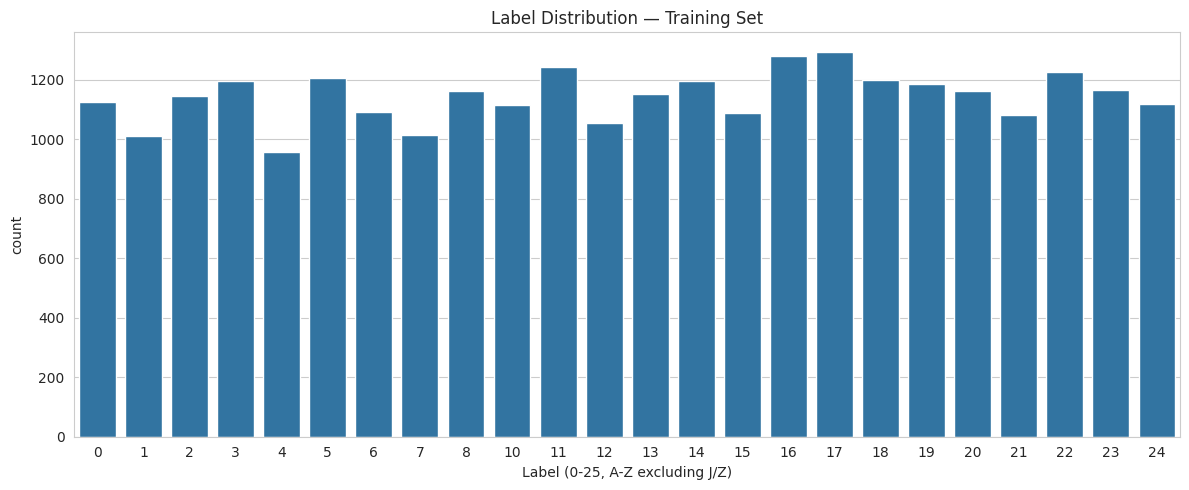

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data=train_df, x="label", order=sorted(train_df["label"].unique()))
plt.title("Label Distribution — Training Set")
plt.xlabel("Label (0-25, A-Z excluding J/Z)")
plt.tight_layout()
plt.savefig("label_distribution_train.png", dpi=150)
plt.show()

In [ ]:
# ---- Cell 9: check class balance numerically ----
label_counts = train_df["label"].value_counts().sort_index()
print(label_counts)



label
0     1126
1     1010
2     1144
3     1196
4      957
5     1204
6     1090
7     1013
8     1162
10    1114
11    1241
12    1055
13    1151
14    1196
15    1088
16    1279
17    1294
18    1199
19    1186
20    1161
21    1082
22    1225
23    1164
24    1118
Name: count, dtype: int64


In [ ]:
print(f"\nMin class count: {label_counts.min()}  Max class count: {label_counts.max()}")


Min class count: 957  Max class count: 1294


In [ ]:
print(f"Imbalance ratio (max/min): {label_counts.max()/label_counts.min():.2f}")

Imbalance ratio (max/min): 1.35


In [ ]:
# ---- Cell 10: pixel value range check ----
pixel_cols = [c for c in train_df.columns if c.startswith("pixel")]
print(f"Number of pixel columns: {len(pixel_cols)}  (should be 784 = 28x28)")
print("Pixel value min:", train_df[pixel_cols].values.min())
print("Pixel value max:", train_df[pixel_cols].values.max())

Number of pixel columns: 784  (should be 784 = 28x28)
Pixel value min: 0
Pixel value max: 255


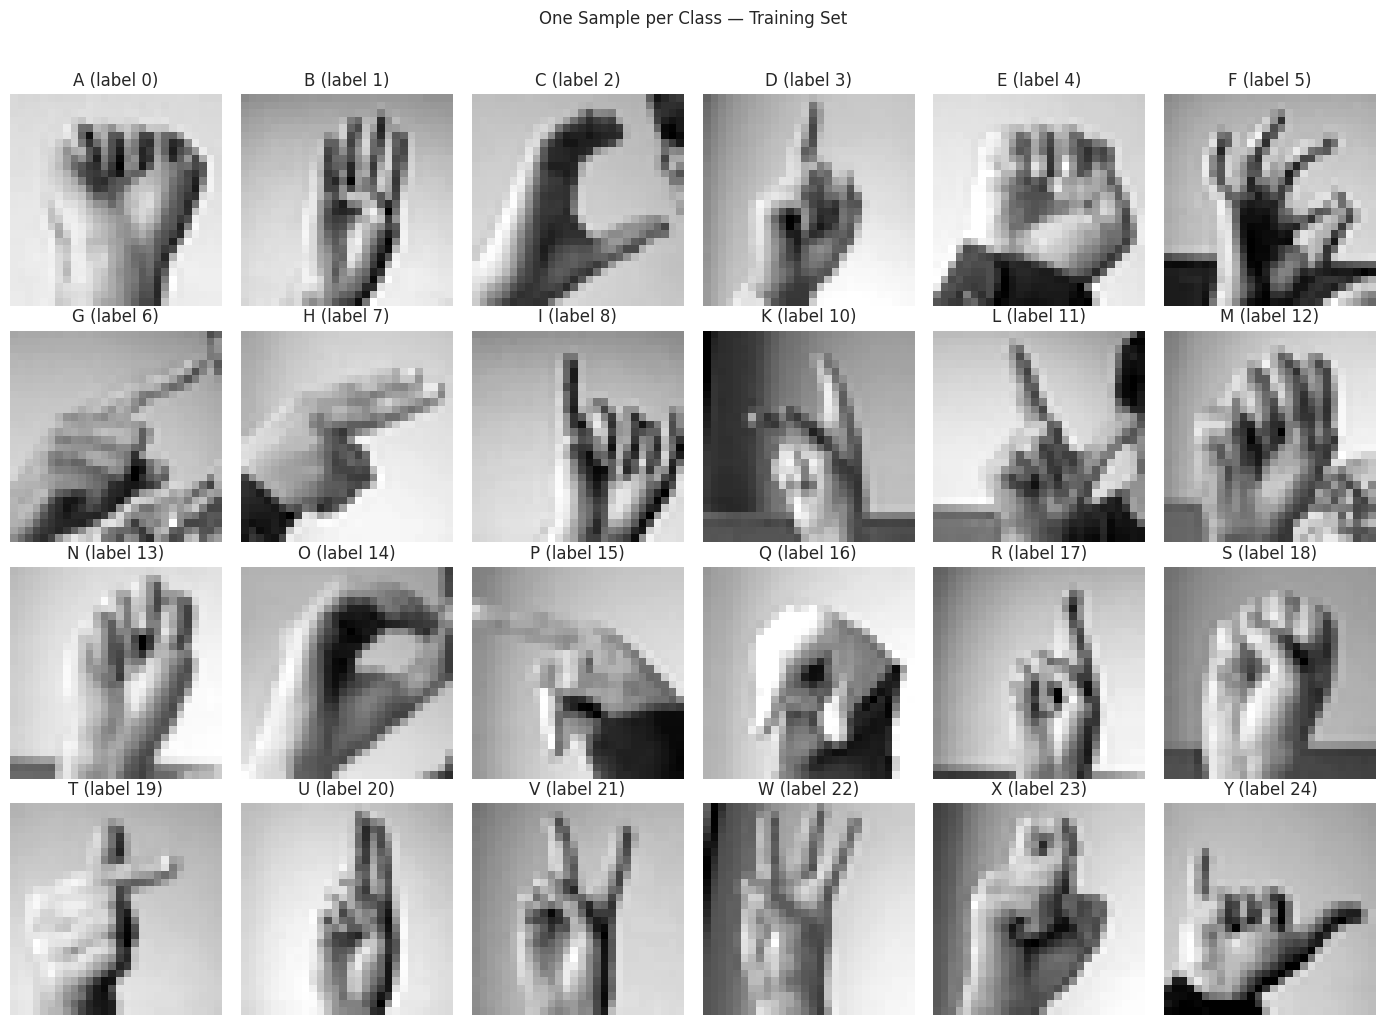

In [ ]:
# ---- Cell 11: visualize sample images per class ----
label_map = {i: chr(65 + i) for i in range(26) if i not in (9, 25)}  # 0->A, 1->B, ... skip J,Z

fig, axes = plt.subplots(4, 6, figsize=(14, 10))
axes = axes.flatten()
shown_labels = sorted(train_df["label"].unique())

for ax, lbl in zip(axes, shown_labels):
    sample = train_df[train_df["label"] == lbl].iloc[0]
    img = sample[pixel_cols].values.reshape(28, 28).astype(np.uint8)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{label_map[lbl]} (label {lbl})")
    ax.axis("off")

# hide unused subplots
for ax in axes[len(shown_labels):]:
    ax.axis("off")

plt.suptitle("One Sample per Class — Training Set", y=1.02)
plt.tight_layout()
plt.savefig("sample_per_class.png", dpi=150)
plt.show()

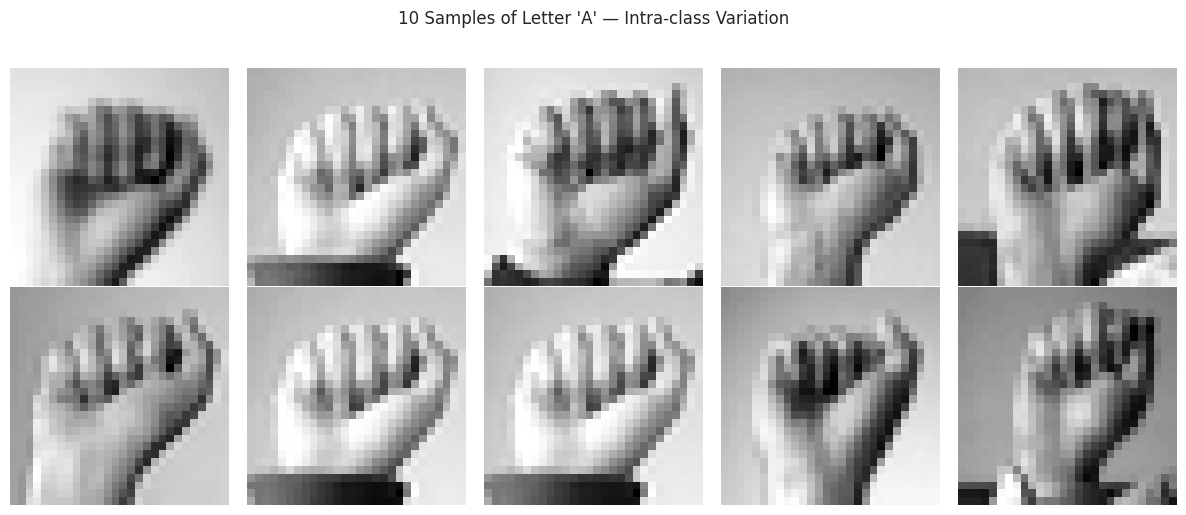

In [ ]:
# ---- Cell 12: multiple samples of the SAME class (check intra-class variation) ----
sample_label = 0  # letter A
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
samples = train_df[train_df["label"] == sample_label].sample(10, random_state=42)

for ax, (_, row) in zip(axes, samples.iterrows()):
    img = row[pixel_cols].values.reshape(28, 28).astype(np.uint8)
    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.suptitle(f"10 Samples of Letter '{label_map[sample_label]}' — Intra-class Variation", y=1.02)
plt.tight_layout()
plt.savefig("intraclass_variation.png", dpi=150)
plt.show()

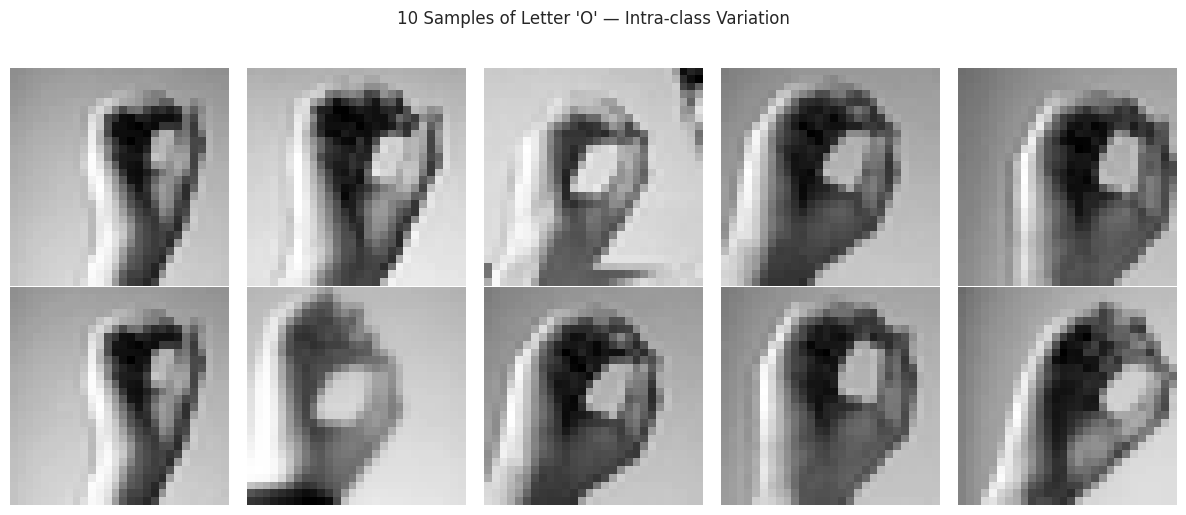

In [ ]:
# ---- Cell 12: multiple samples of the SAME class (check intra-class variation) ----
sample_label = 14  # letter 0
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
samples = train_df[train_df["label"] == sample_label].sample(10, random_state=42)

for ax, (_, row) in zip(axes, samples.iterrows()):
    img = row[pixel_cols].values.reshape(28, 28).astype(np.uint8)
    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.suptitle(f"10 Samples of Letter '{label_map[sample_label]}' — Intra-class Variation", y=1.02)
plt.tight_layout()
plt.savefig("intraclass_variation.png", dpi=150)
plt.show()

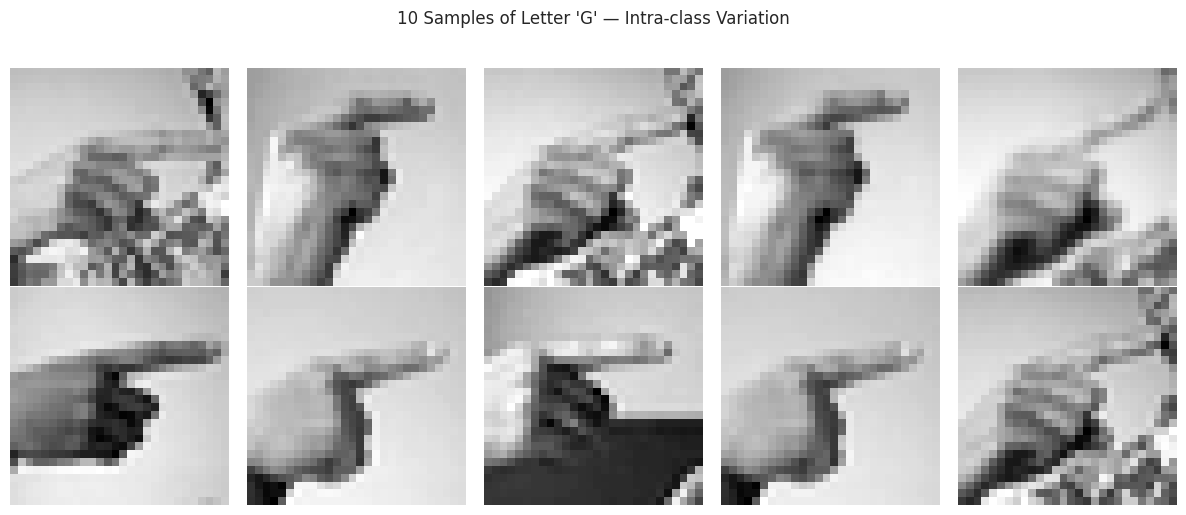

In [ ]:
# ---- Cell 12: multiple samples of the SAME class (check intra-class variation) ----
sample_label = 6 # letter G
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
samples = train_df[train_df["label"] == sample_label].sample(10, random_state=42)

for ax, (_, row) in zip(axes, samples.iterrows()):
    img = row[pixel_cols].values.reshape(28, 28).astype(np.uint8)
    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.suptitle(f"10 Samples of Letter '{label_map[sample_label]}' — Intra-class Variation", y=1.02)
plt.tight_layout()
plt.savefig("intraclass_variation.png", dpi=150)
plt.show()

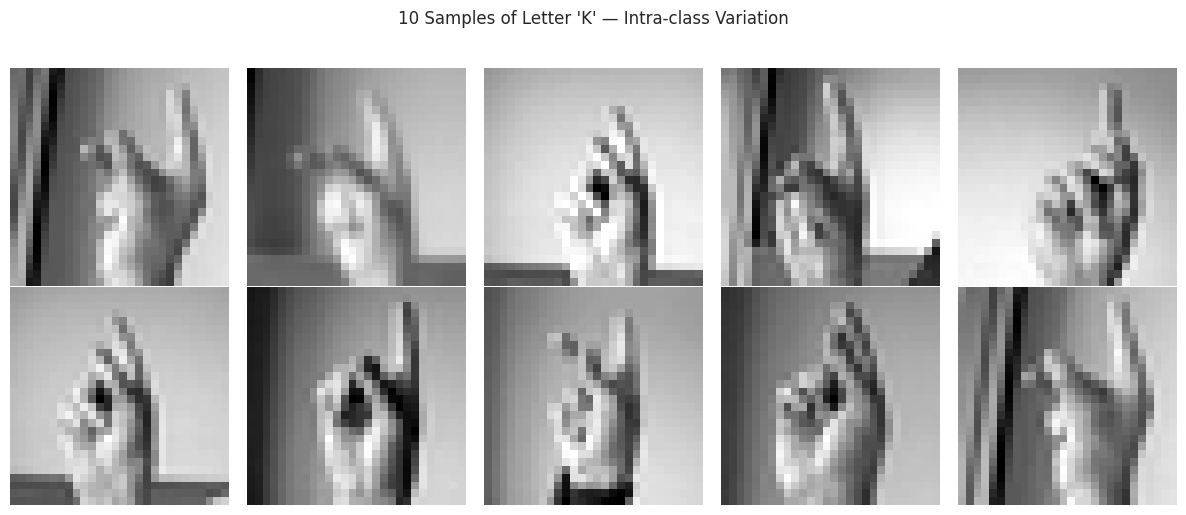

In [ ]:
# ---- Cell 12: multiple samples of the SAME class (check intra-class variation) ----
sample_label = 10  # K letter
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
samples = train_df[train_df["label"] == sample_label].sample(10, random_state=42)

for ax, (_, row) in zip(axes, samples.iterrows()):
    img = row[pixel_cols].values.reshape(28, 28).astype(np.uint8)
    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.suptitle(f"10 Samples of Letter '{label_map[sample_label]}' — Intra-class Variation", y=1.02)
plt.tight_layout()
plt.savefig("intraclass_variation.png", dpi=150)
plt.show()

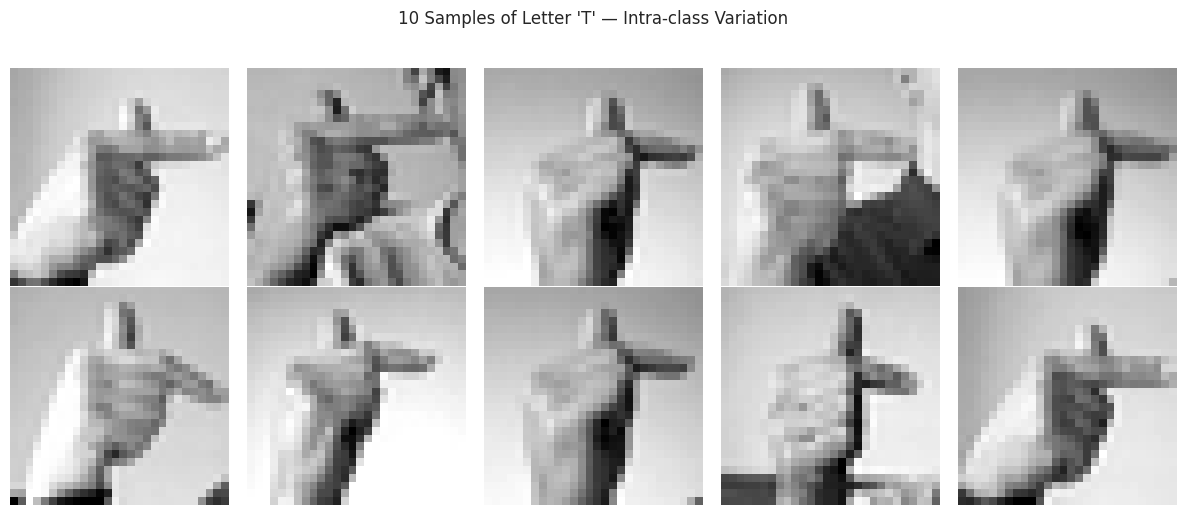

In [ ]:
# ---- Cell 12: multiple samples of the SAME class (check intra-class variation) ----
sample_label = 19 # T letter
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
samples = train_df[train_df["label"] == sample_label].sample(10, random_state=42)

for ax, (_, row) in zip(axes, samples.iterrows()):
    img = row[pixel_cols].values.reshape(28, 28).astype(np.uint8)
    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.suptitle(f"10 Samples of Letter '{label_map[sample_label]}' — Intra-class Variation", y=1.02)
plt.tight_layout()
plt.savefig("intraclass_variation.png", dpi=150)
plt.show()

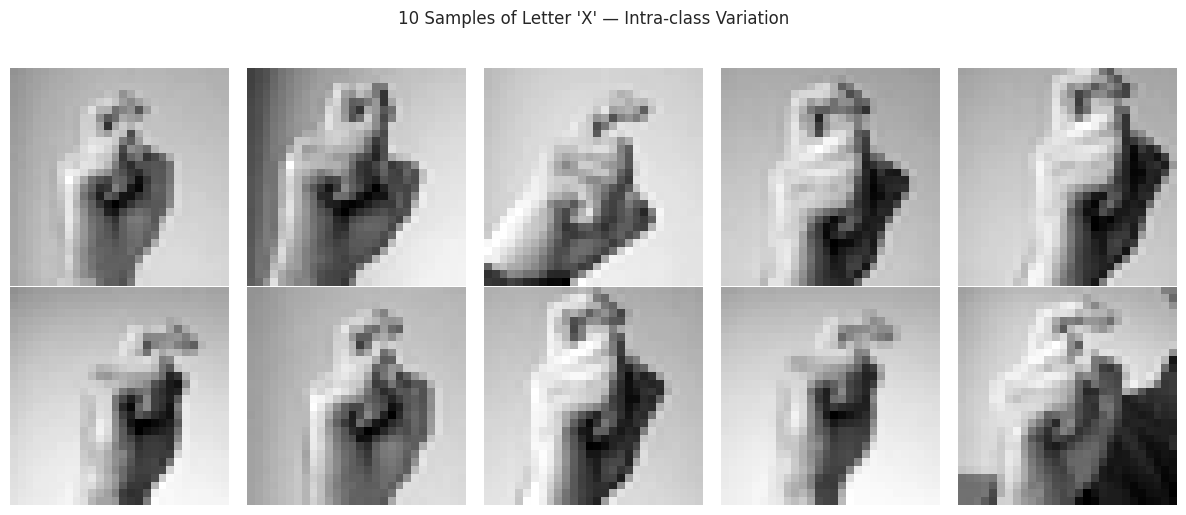

In [ ]:
# ---- Cell 12: multiple samples of the SAME class (check intra-class variation) ----
sample_label = 23  # letter X
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
samples = train_df[train_df["label"] == sample_label].sample(10, random_state=42)

for ax, (_, row) in zip(axes, samples.iterrows()):
    img = row[pixel_cols].values.reshape(28, 28).astype(np.uint8)
    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.suptitle(f"10 Samples of Letter '{label_map[sample_label]}' — Intra-class Variation", y=1.02)
plt.tight_layout()
plt.savefig("intraclass_variation.png", dpi=150)
plt.show()

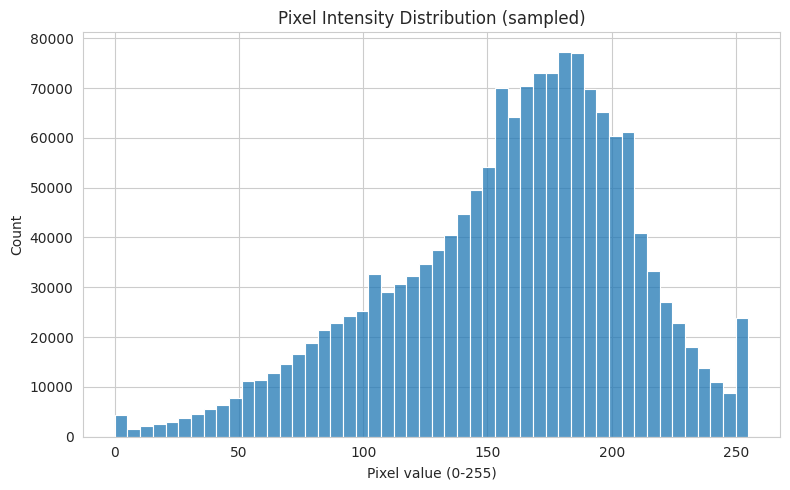

In [ ]:
# ---- Cell 13: pixel intensity distribution (overall) ----
plt.figure(figsize=(8, 5))
sample_pixels = train_df[pixel_cols].sample(2000, axis=0, random_state=42).values.flatten()
sns.histplot(sample_pixels, bins=50)
plt.title("Pixel Intensity Distribution (sampled)")
plt.xlabel("Pixel value (0-255)")
plt.tight_layout()
plt.savefig("pixel_intensity_dist.png", dpi=150)
plt.show()

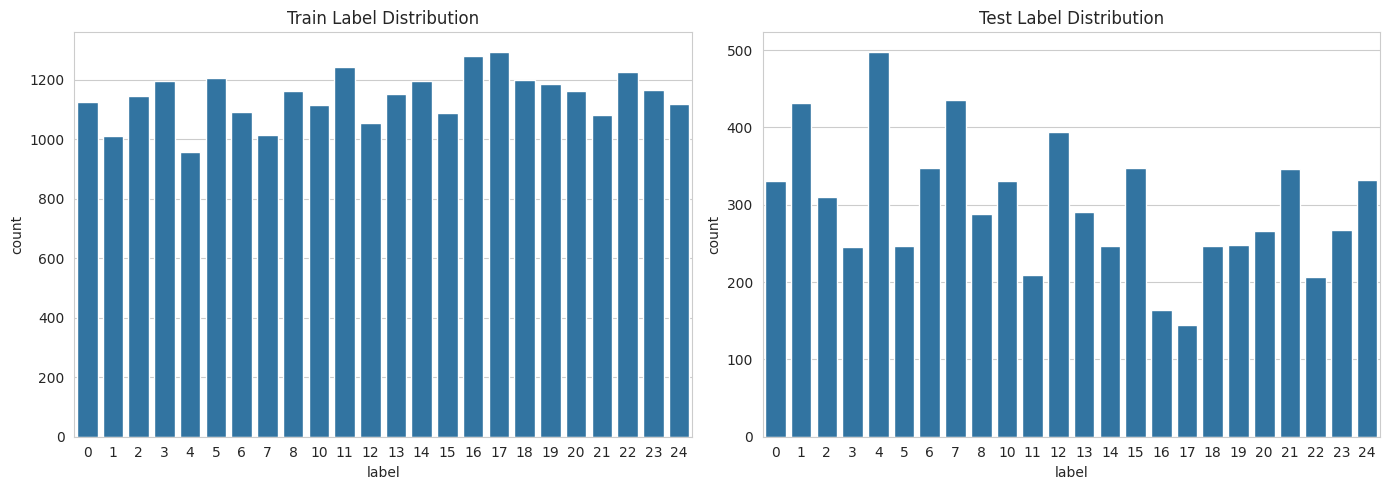

In [ ]:
# ---- Cell 14: compare train vs test label distribution ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=train_df, x="label", order=sorted(train_df["label"].unique()), ax=axes[0])
axes[0].set_title("Train Label Distribution")
sns.countplot(data=test_df, x="label", order=sorted(test_df["label"].unique()), ax=axes[1])
axes[1].set_title("Test Label Distribution")
plt.tight_layout()
plt.savefig("train_vs_test_distribution.png", dpi=150)
plt.show()

In [ ]:
print("\n=== Summary ===")


=== Summary ===


In [ ]:

print(f"Train: {train_df.shape[0]} images, {train_df['label'].nunique()} classes")


Train: 27455 images, 24 classes


In [ ]:
print(f"Test: {test_df.shape[0]} images, {test_df['label'].nunique()} classes")


Test: 7172 images, 24 classes


In [ ]:
print(f"Image size: 28x28 grayscale (784 pixels flattened)")


Image size: 28x28 grayscale (784 pixels flattened)


In [ ]:
print(f"Missing letters: J, Z (require motion, excluded from static dataset)")

Missing letters: J, Z (require motion, excluded from static dataset)


In [ ]:
# ============================================================
# Sign Language MNIST — Step 3: Reshape, Normalize, Split, Augment
# ============================================================


In [ ]:
# ---- Cell 15: imports ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# ---- Cell 16: separate labels and pixels ----
pixel_cols = [c for c in train_df.columns if c.startswith("pixel")]

X_train_full = train_df[pixel_cols].values
y_train_full = train_df["label"].values

X_test = test_df[pixel_cols].values
y_test = test_df["label"].values

In [ ]:
print("X_train_full shape:", X_train_full.shape)
print("X_test shape:", X_test.shape)

X_train_full shape: (27455, 784)
X_test shape: (7172, 784)


In [ ]:
print("y_train_full shape:", y_train_full.shape)
print("y_test shape:", y_test.shape)

y_train_full shape: (27455,)
y_test shape: (7172,)


In [ ]:
# ---- Cell 17 (revised): reshape only — do NOT normalize yet ----
X_train_full = X_train_full.reshape(-1, 28, 28, 1).astype("float32")  # stays 0-255 range
X_test = X_test.reshape(-1, 28, 28, 1).astype("float32")              # stays 0-255 range



In [ ]:
print("Reshaped X_train_full:", X_train_full.shape, " range:", X_train_full.min(), "-", X_train_full.max())
print("Reshaped X_test:", X_test.shape, " range:", X_test.min(), "-", X_test.max())

Reshaped X_train_full: (27455, 28, 28, 1)  range: 0.0 - 255.0
Reshaped X_test: (7172, 28, 28, 1)  range: 0.0 - 255.0


In [ ]:
# ---- Cell 18 (revised): SKIP manual normalization here ----
# Normalization now happens inside ImageDataGenerator(rescale=1./255) instead,
# so it's applied consistently AFTER augmentation, avoiding the brightness_range
# double-scaling bug that caused near-black images last run.
# (Nothing to run in this cell — normalization moved to Cell 22 below.)


In [ ]:
# ---- Cell 19: re-map labels — unchanged, same as before ----
unique_labels = sorted(train_df["label"].unique())
label_to_index = {orig: idx for idx, orig in enumerate(unique_labels)}
index_to_label = {idx: orig for orig, idx in label_to_index.items()}
index_to_letter = {idx: chr(65 + orig) for idx, orig in index_to_label.items()}

y_train_full_mapped = np.array([label_to_index[l] for l in y_train_full])
y_test_mapped = np.array([label_to_index[l] for l in y_test])
num_classes = len(unique_labels)

In [ ]:
# ---- Cell 20: one-hot encode — unchanged ----
y_train_full_cat = to_categorical(y_train_full_mapped, num_classes=num_classes)
y_test_cat = to_categorical(y_test_mapped, num_classes=num_classes)



In [ ]:
# ---- Cell 21: train/val split — unchanged, still on raw 0-255 X ----
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full_cat,
    test_size=0.15,
    random_state=42,
    stratify=y_train_full_mapped
)
print("X_train:", X_train.shape, " X_val:", X_val.shape, " X_test:", X_test.shape)
print("X_train pixel range:", X_train.min(), "-", X_train.max())  # should still be 0-255 here


X_train: (23336, 28, 28, 1)  X_val: (4119, 28, 28, 1)  X_test: (7172, 28, 28, 1)
X_train pixel range: 0.0 - 255.0


In [ ]:
# ---- Cell 22: augmentation generator WITH rescale built in ----
train_datagen = ImageDataGenerator(
    rescale=1./255,              # normalization now happens here, after augmentation
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest",
)
train_datagen.fit(X_train)
train_generator = train_datagen.flow(X_train, y_train, batch_size=64)

# Validation and test also need rescale=1./255 applied (no augmentation, just normalization)
val_test_datagen = ImageDataGenerator(rescale=1./255)
val_generator = val_test_datagen.flow(X_val, y_val, batch_size=64, shuffle=False)

# For test set, normalize directly (no need for a generator since no augmentation)
X_test_normalized = X_test / 255.0

In [ ]:
# ---- Cell 23 (revised): sanity-check augmented samples again ----
sample_batch_x, sample_batch_y = next(train_generator)
print("Augmented batch pixel range:", sample_batch_x.min(), "-", sample_batch_x.max())  # should be ~0-1, NOT all near 0

Augmented batch pixel range: 0.0 - 1.0


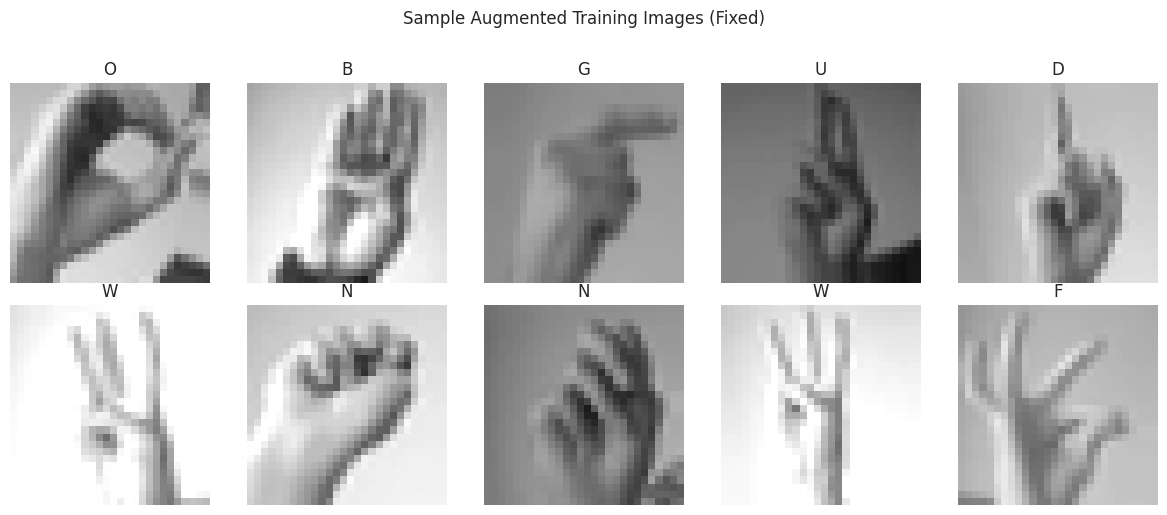

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
for ax, img, lbl in zip(axes, sample_batch_x[:10], sample_batch_y[:10]):
    ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
    idx = np.argmax(lbl)
    ax.set_title(index_to_letter[idx])
    ax.axis("off")
plt.suptitle("Sample Augmented Training Images (Fixed)", y=1.02)
plt.tight_layout()
plt.savefig("augmented_samples_fixed.png", dpi=150)
plt.show()


In [ ]:

print("\n=== Ready for model training ===")
print(f"Train: {X_train.shape[0]} images | Val: {X_val.shape[0]} images | Test: {X_test.shape[0]} images")
print(f"Classes: {num_classes}")


=== Ready for model training ===
Train: 23336 images | Val: 4119 images | Test: 7172 images
Classes: 24


In [ ]:
# ============================================================
# Sign Language MNIST — Step 4: CNN Architecture & Training
# ============================================================


In [ ]:

# ---- Cell 24: imports ----
# Sequential = simple layer-by-layer model container (fine for a single-path CNN).
# Conv2D/MaxPooling2D = the actual feature-extraction layers.
# BatchNormalization = stabilizes/speeds up training by normalizing activations
#   between layers — helps a lot on image data like this.
# Dropout = randomly zeroes some neurons during training to prevent overfitting.
# callbacks = tools that watch training and react (stop early, save best model, etc.)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Flatten, Dense, Dropout, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

tf.random.set_seed(42)


In [ ]:
# ---- Cell 25: build the CNN architecture ----
model = Sequential([
    Input(shape=(28, 28, 1)),  # each input is one 28x28 grayscale image

    # ---- Block 1: learn simple, low-level features (edges, curves) ----
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),          # normalizes outputs -> faster, more stable training
    MaxPooling2D((2, 2)),          # shrinks 28x28 -> 14x14, keeps strongest features
    Dropout(0.25),                 # randomly drops 25% of activations -> reduces overfitting

    # ---- Block 2: learn more complex shapes (finger combinations, hand contours) ----
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),          # 14x14 -> 7x7
    Dropout(0.25),

    # ---- Block 3: learn high-level, abstract patterns specific to each letter ----
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),          # 7x7 -> 3x3
    Dropout(0.25),

    # ---- Classifier head: turn extracted features into a class prediction ----
    Flatten(),                     # 3x3x128 feature maps -> a single flat vector
    Dense(256, activation="relu"), # combines all features to reason about the letter
    BatchNormalization(),
    Dropout(0.4),                  # stronger dropout here since this layer is most
                                    # prone to overfitting (most parameters live here)
    Dense(num_classes, activation="softmax"),  # outputs a probability per letter class
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 395,928 (1.51 MB)

 Trainable params: 394,968 (1.51 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# ---- Cell 26: compile the model ----
# Adam: adaptive optimizer, good default choice, adjusts learning rate per-weight.
# categorical_crossentropy: correct loss for multi-class, one-hot encoded labels.
# metrics=["accuracy"]: track classification accuracy during training.
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)


In [ ]:

# ---- Cell 27: set up training callbacks ----
# EarlyStopping: stops training once val_loss stops improving, restores the
#   best-performing weights instead of whatever the model ended on.
# ReduceLROnPlateau: shrinks the learning rate when progress stalls, letting
#   the model fine-tune with smaller steps instead of overshooting.
# ModelCheckpoint: saves the single best model to disk as training progresses,
#   so you always have a usable file even if a later epoch gets worse.
early_stop = EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6
)
checkpoint = ModelCheckpoint(
    "best_sign_language_model.keras", monitor="val_accuracy",
    save_best_only=True
)

In [ ]:
# ---- Cell  28: train the model ----
# Uses train_generator (augmented, batches of 64) for training data, and
# val_generator (rescaled only, no augmentation) to evaluate after each epoch.
# steps_per_epoch/validation_steps tell Keras how many batches make up one
# full pass over the data, since generators don't have a fixed __len__ Keras
# can always infer automatically in older TF versions.
steps_per_epoch = len(X_train) // 64
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=len(X_val) // 64,
    epochs=40,
    callbacks=[early_stop, reduce_lr, checkpoint],
)

Epoch 1/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.4931 - loss: 1.6786 - val_accuracy: 0.2065 - val_loss: 2.7813 - learning_rate: 0.0010
Epoch 2/40
  1/364 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7188 - loss: 0.7523

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 834us/step - accuracy: 0.7188 - loss: 0.7523 - val_accuracy: 0.1960 - val_loss: 2.8326 - learning_rate: 0.0010
Epoch 3/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.7932 - loss: 0.6132 - val_accuracy: 0.9001 - val_loss: 0.2678 - learning_rate: 0.0010
Epoch 4/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9219 - loss: 0.3158 - val_accuracy: 0.9233 - val_loss: 0.2128 - learning_rate: 0.0010
Epoch 5/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.8802 - loss: 0.3543 - val_accuracy: 0.9944 - val_loss: 0.0308 - learning_rate: 0.0010
Epoch 6/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8750 - loss: 0.3147 - val_accuracy: 0.9966 - val_loss: 0.0220 - learning_rate: 0.0010
Epoch 7/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9178 - loss: 0.2510 - val_accuracy: 0.9851 - val_loss: 0.0627 - learning_rate: 0.0010
Epoch 8/40
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8906 - loss: 0.4215 - val

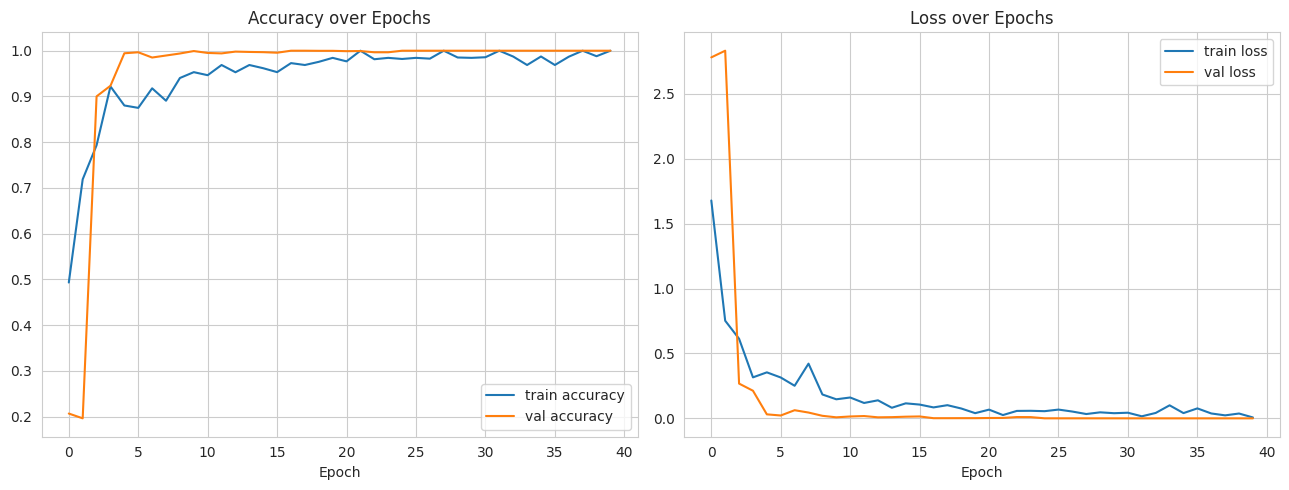

In [ ]:
# ---- Cell  29: plot training curves ----
# Shows whether the model is still improving (curves still dropping/rising)
# or has plateaued/overfit (train keeps improving, val gets worse/flat) —
# the single most useful diagnostic plot for any training run.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history.history["accuracy"], label="train accuracy")
axes[0].plot(history.history["val_accuracy"], label="val accuracy")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train loss")
axes[1].plot(history.history["val_loss"], label="val loss")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("cnn_training_curves.png", dpi=150)
plt.show()



In [ ]:
# ---- Cell 30: evaluate on the held-out TEST set ----
# This is the real, honest performance number — test set was never touched
# during training or hyperparameter tuning, and has no augmentation applied.
test_loss, test_accuracy = model.evaluate(X_test_normalized, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.0010
Test Accuracy: 0.9999


In [ ]:
# ============================================================
# Sign Language MNIST — Step 5: Detailed Evaluation
# ============================================================


In [ ]:
# ---- Cell 31: imports ----
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
# ---- Cell 32: get predictions on the test set ----
y_pred_probs = model.predict(X_test_normalized)
y_pred = np.argmax(y_pred_probs, axis=1)          # predicted class index (0-23)
y_true = np.argmax(y_test_cat, axis=1)            # true class index (0-23)

# Convert indices back to actual letters for readability
y_pred_letters = [index_to_letter[i] for i in y_pred]
y_true_letters = [index_to_letter[i] for i in y_true]

print(f"Total test samples: {len(y_true)}")
print(f"Correct predictions: {(y_pred == y_true).sum()}")
print(f"Incorrect predictions: {(y_pred != y_true).sum()}")


225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Total test samples: 7172
Correct predictions: 7171
Incorrect predictions: 1


In [ ]:
# ---- Cell 33: classification report (per-class precision/recall/F1) ----
target_names = [index_to_letter[i] for i in range(num_classes)]
report = classification_report(y_true, y_pred, target_names=target_names, digits=4)
print(report)


              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000       331
           B     1.0000    1.0000    1.0000       432
           C     1.0000    1.0000    1.0000       310
           D     1.0000    1.0000    1.0000       245
           E     1.0000    1.0000    1.0000       498
           F     1.0000    1.0000    1.0000       247
           G     1.0000    0.9971    0.9986       348
           H     0.9977    1.0000    0.9989       436
           I     1.0000    1.0000    1.0000       288
           K     1.0000    1.0000    1.0000       331
           L     1.0000    1.0000    1.0000       209
           M     1.0000    1.0000    1.0000       394
           N     1.0000    1.0000    1.0000       291
           O     1.0000    1.0000    1.0000       246
           P     1.0000    1.0000    1.0000       347
           Q     1.0000    1.0000    1.0000       164
           R     1.0000    1.0000    1.0000       144
           S     1.0000    

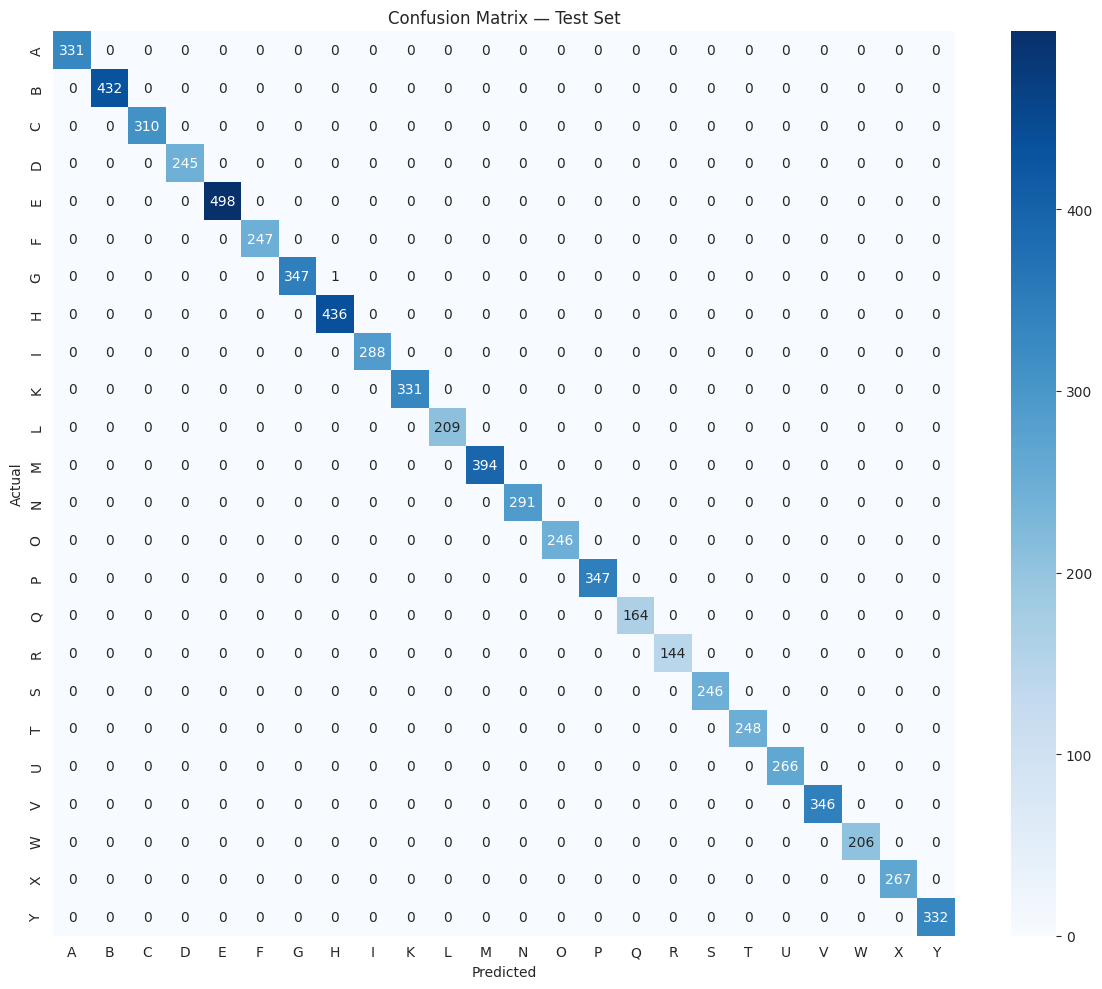

In [ ]:
# ---- Cell 34: confusion matrix ----
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


Number of misclassified samples: 1


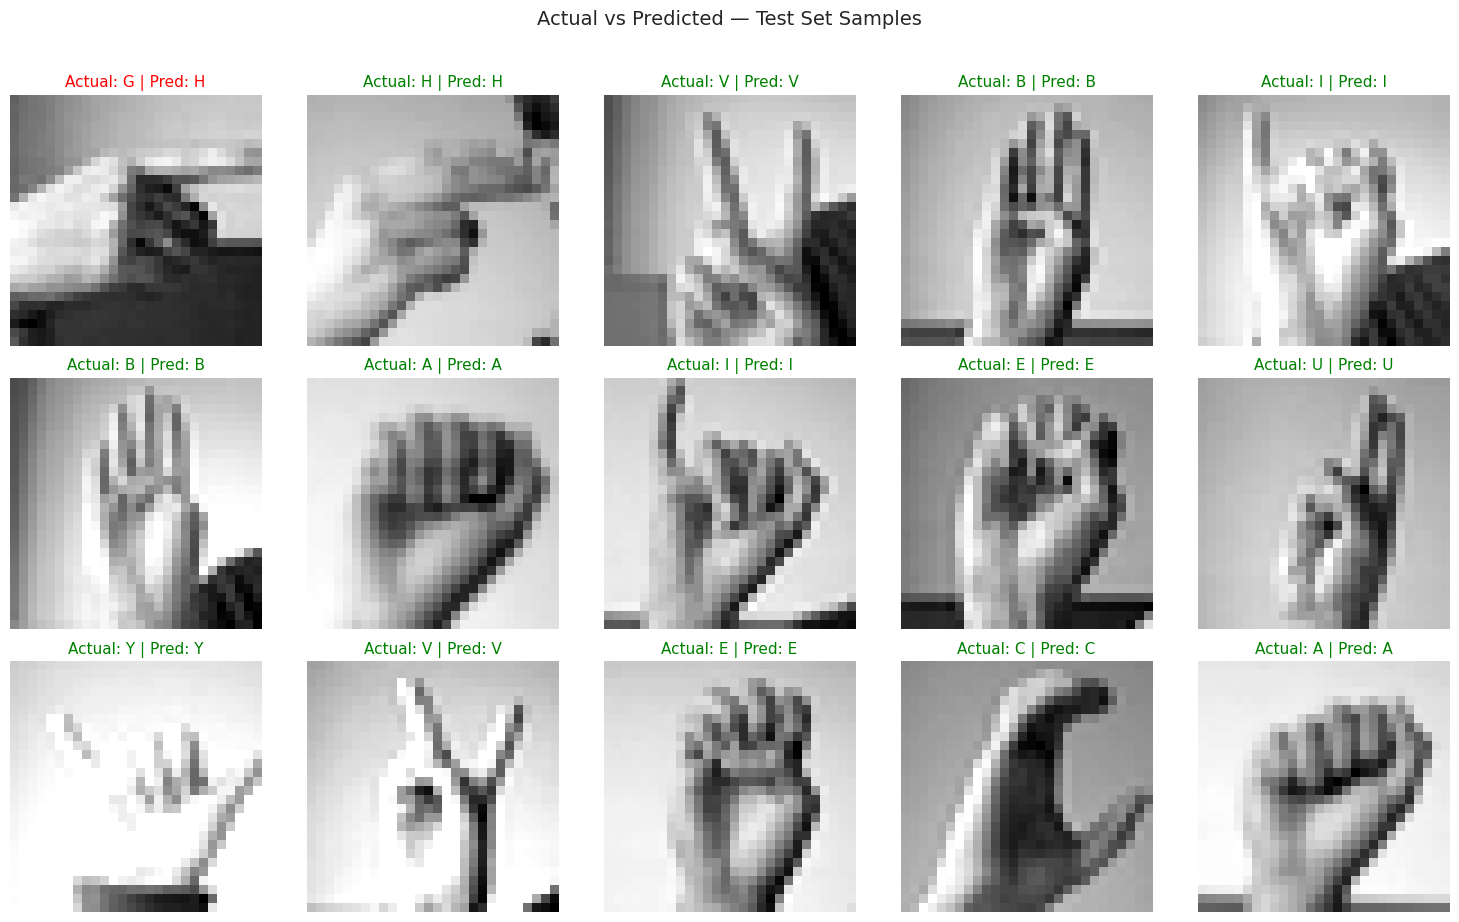

In [ ]:
# ---- Cell 35: actual vs predicted — sample grid (mix of correct + incorrect if any exist) ----
misclassified_idx = np.where(y_pred != y_true)[0]
correct_idx = np.where(y_pred == y_true)[0]

print(f"\nNumber of misclassified samples: {len(misclassified_idx)}")

# Build a sample: prioritize showing misclassified ones (if any), fill rest with correct
n_show = 15
if len(misclassified_idx) >= n_show:
    show_idx = np.random.choice(misclassified_idx, n_show, replace=False)
elif len(misclassified_idx) > 0:
    show_idx = np.concatenate([
        misclassified_idx,
        np.random.choice(correct_idx, n_show - len(misclassified_idx), replace=False)
    ])
else:
    show_idx = np.random.choice(correct_idx, n_show, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for ax, idx in zip(axes, show_idx):
    img = X_test_normalized[idx].squeeze()
    actual = y_true_letters[idx]
    pred = y_pred_letters[idx]
    is_correct = actual == pred
    color = "green" if is_correct else "red"

    ax.imshow(img, cmap="gray")
    ax.set_title(f"Actual: {actual} | Pred: {pred}", color=color, fontsize=11)
    ax.axis("off")

plt.suptitle("Actual vs Predicted — Test Set Samples", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("actual_vs_predicted_grid.png", dpi=150)
plt.show()


In [ ]:
# ---- Cell 36: build a full actual-vs-predicted table (like we did for MDCAT) ----
results_table = pd.DataFrame({
    "sample_index": range(len(y_true)),
    "actual_letter": y_true_letters,
    "predicted_letter": y_pred_letters,
    "confidence": y_pred_probs.max(axis=1).round(4),
    "correct": (y_pred == y_true),
})
results_table.to_csv("test_predictions_table.csv", index=False)
print(results_table.head(20))

    sample_index actual_letter predicted_letter  confidence  correct
0              0             G                G      1.0000     True
1              1             F                F      1.0000     True
2              2             K                K      0.9996     True
3              3             A                A      1.0000     True
4              4             D                D      0.9999     True
5              5             V                V      1.0000     True
6              6             K                K      1.0000     True
7              7             O                O      1.0000     True
8              8             D                D      0.9999     True
9              9             H                H      1.0000     True
10            10             I                I      1.0000     True
11            11             I                I      1.0000     True
12            12             V                V      1.0000     True
13            13             M    

In [ ]:
# ---- Cell 37: if misclassifications exist, show which letters get confused ----
if len(misclassified_idx) > 0:
    mistakes = results_table[~results_table["correct"]]
    print("\nMisclassification pairs (actual -> predicted):")
    print(mistakes.groupby(["actual_letter", "predicted_letter"]).size().sort_values(ascending=False))
else:
    print("\nNo misclassifications on this test set — see the leakage caveat above before "
          "treating this as a true measure of real-world performance.")


Misclassification pairs (actual -> predicted):
actual_letter  predicted_letter
G              H                   1
dtype: int64


In [ ]:
# ============================================================
# ASL Alphabet — Step 7: Download & Prepare Data
# ============================================================


In [ ]:
# ---- Cell 1: download via Kaggle API (reuse existing kaggle.json credentials) ----
!kaggle datasets download -d grassknoted/asl-alphabet
!unzip -q asl-alphabet.zip -d asl_data
!ls asl_data

# The dataset structure is typically:
# asl_data/asl_alphabet_train/asl_alphabet_train/<A,B,C,...,del,nothing,space>/*.jpg
# asl_data/asl_alphabet_test/asl_alphabet_test/*.jpg  (a handful of loose test images)


Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
100% 1.03G/1.03G [00:16<00:00, 67.1MB/s]

asl_alphabet_test  asl_alphabet_train


In [ ]:
# ---- Cell 2: check folder structure ----
import os
train_dir = "asl_data/asl_alphabet_train/asl_alphabet_train"
print("Classes found:", sorted(os.listdir(train_dir)))
print("Number of classes:", len(os.listdir(train_dir)))

sample_class = os.listdir(train_dir)[0]
sample_class_path = os.path.join(train_dir, sample_class)
print(f"\nImages in '{sample_class}' class: {len(os.listdir(sample_class_path))}")


Classes found: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Number of classes: 29

Images in 'Z' class: 3000


In [ ]:
# ---- Cell 3: imports ----
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = 96          # MobileNetV2 works well at 96x96 or 224x224; 96 keeps training fast
BATCH_SIZE = 32


In [ ]:
# ---- Cell 4: data generators with train/val split + augmentation ----
# ASL Alphabet has ~3000 images per class in ONE folder (no separate val folder),
# so we use validation_split to carve out a validation set from the training data.
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # MobileNetV2's expected preprocessing
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    validation_split=0.15,
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42,
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42,
)

print("Class indices mapping:", train_gen.class_indices)
num_classes_asl = len(train_gen.class_indices)
print("Number of classes:", num_classes_asl)

# Save this mapping — needed to decode predictions later, same role as
# index_to_letter was for the MNIST version.
asl_index_to_class = {v: k for k, v in train_gen.class_indices.items()}


Found 73950 images belonging to 29 classes.
Found 13050 images belonging to 29 classes.
Class indices mapping: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25, 'del': 26, 'nothing': 27, 'space': 28}
Number of classes: 29


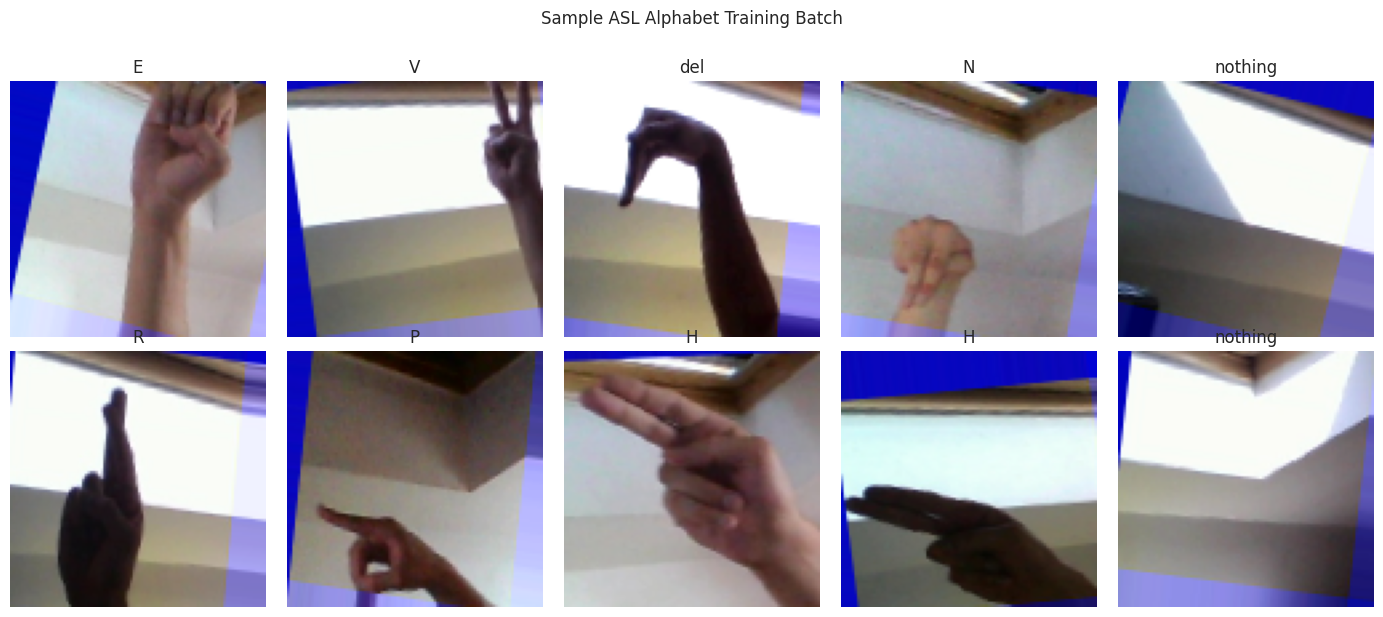


Train batches per epoch: 2311
Val batches per epoch: 408


In [ ]:
# ---- Cell 5: visualize a batch to confirm everything loaded correctly ----
sample_x, sample_y = next(train_gen)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()
for ax, img, lbl in zip(axes, sample_x[:10], sample_y[:10]):
    # undo MobileNetV2 preprocessing just for display purposes
    display_img = (img - img.min()) / (img.max() - img.min())
    ax.imshow(display_img)
    idx = np.argmax(lbl)
    ax.set_title(asl_index_to_class[idx])
    ax.axis("off")
plt.suptitle("Sample ASL Alphabet Training Batch", y=1.02)
plt.tight_layout()
plt.savefig("asl_sample_batch.png", dpi=150)
plt.show()

print(f"\nTrain batches per epoch: {len(train_gen)}")
print(f"Val batches per epoch: {len(val_gen)}")

In [ ]:
# ============================================================
# ASL Alphabet — Step 8: Transfer Learning with MobileNetV2
# ============================================================


In [ ]:

# ---- Cell 1: imports ----
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt


In [ ]:
# ---- Cell 2: load MobileNetV2 pretrained on ImageNet, without its top layer ----
# include_top=False strips off ImageNet's original 1000-class output layer,
# so we can attach our own 29-class head instead.
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
)

# Freeze the base model initially — we only train our new head first,
# so we don't wreck the pretrained ImageNet features with random gradients
# from an untrained classifier head.
base_model.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# ---- Cell 3: attach a new classification head ----
x = base_model.output
x = GlobalAveragePooling2D()(x)     # collapse spatial feature maps into a single vector
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes_asl, activation="softmax")(x)

model_asl = Model(inputs=base_model.input, outputs=predictions)

model_asl.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model_asl.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,425,693 (9.25 MB)

 Trainable params: 167,709 (655.11 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ---- Cell 4: callbacks ----
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
checkpoint = ModelCheckpoint("best_asl_model_phase1.keras", monitor="val_accuracy", save_best_only=True)


In [ ]:
# ---- Cell 5: Phase 1 — train only the new head (base frozen) ----
# This is fast since MobileNetV2's ~2.2M pretrained parameters aren't being updated,
# only our small new head (a few hundred thousand params).
history_phase1 = model_asl.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint],
)

Epoch 1/10
2311/2311 ━━━━━━━━━━━━━━━━━━━━ 357s 147ms/step - accuracy: 0.7935 - loss: 0.6599 - val_accuracy: 0.7512 - val_loss: 0.8205 - learning_rate: 0.0010
Epoch 2/10
2311/2311 ━━━━━━━━━━━━━━━━━━━━ 308s 133ms/step - accuracy: 0.8878 - loss: 0.3351 - val_accuracy: 0.7553 - val_loss: 0.8837 - learning_rate: 0.0010
Epoch 3/10
2311/2311 ━━━━━━━━━━━━━━━━━━━━ 313s 136ms/step - accuracy: 0.9051 - loss: 0.2830 - val_accuracy: 0.7721 - val_loss: 0.8459 - learning_rate: 0.0010
Epoch 4/10
2311/2311 ━━━━━━━━━━━━━━━━━━━━ 313s 136ms/step - accuracy: 0.9142 - loss: 0.2581 - val_accuracy: 0.7836 - val_loss: 0.8041 - learning_rate: 0.0010
Epoch 5/10
2311/2311 ━━━━━━━━━━━━━━━━━━━━ 306s 133ms/step - accuracy: 0.9194 - loss: 0.2360 - val_accuracy: 0.7744 - val_loss: 0.8152 - learning_rate: 0.0010
Epoch 6/10
2311/2311 ━━━━━━━━━━━━━━━━━━━━ 345s 149ms/step - accuracy: 0.9233 - loss: 0.2281 - val_accuracy: 0.7821 - val_loss: 0.8384 - learning_rate: 0.0010
Epoch 7/10
2311/2311 ━━━━━━━━━━━━━━━━━━━━ 313s 135ms

In [ ]:
# ---- Cell 6: Phase 2 — fine-tune the top layers of MobileNetV2 itself ----
# Now unfreeze the LAST portion of the base model (not all of it — the earliest
# layers learn generic edges/textures useful for any image task, no need to
# retrain those). Only fine-tune the later layers that capture more
# task-specific patterns.
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30  # unfreeze only the last 30 layers
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Use a much smaller learning rate for fine-tuning — large updates here would
# destroy the pretrained features we're trying to adapt, not replace.
model_asl.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

checkpoint2 = ModelCheckpoint("best_asl_model_finetuned.keras", monitor="val_accuracy", save_best_only=True)

history_phase2 = model_asl.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint2],
)

Epoch 1/10
2311/2311 ━━━━━━━━━━━━━━━━━━━━ 351s 145ms/step - accuracy: 0.8043 - loss: 0.7541 - val_accuracy: 0.7811 - val_loss: 0.8959 - learning_rate: 1.0000e-05
Epoch 2/10
2311/2311 ━━━━━━━━━━━━━━━━━━━━ 319s 138ms/step - accuracy: 0.8991 - loss: 0.3219 - val_accuracy: 0.7926 - val_loss: 0.8142 - learning_rate: 1.0000e-05
Epoch 3/10
2311/2311 ━━━━━━━━━━━━━━━━━━━━ 320s 138ms/step - accuracy: 0.9254 - loss: 0.2287 - val_accuracy: 0.8162 - val_loss: 0.7344 - learning_rate: 1.0000e-05
Epoch 4/10
2311/2311 ━━━━━━━━━━━━━━━━━━━━ 318s 138ms/step - accuracy: 0.9415 - loss: 0.1760 - val_accuracy: 0.8247 - val_loss: 0.7177 - learning_rate: 1.0000e-05
Epoch 5/10
2311/2311 ━━━━━━━━━━━━━━━━━━━━ 317s 137ms/step - accuracy: 0.9525 - loss: 0.1439 - val_accuracy: 0.8237 - val_loss: 0.7384 - learning_rate: 1.0000e-05
Epoch 6/10
2311/2311 ━━━━━━━━━━━━━━━━━━━━ 321s 139ms/step - accuracy: 0.9600 - loss: 0.1192 - val_accuracy: 0.8350 - val_loss: 0.6816 - learning_rate: 1.0000e-05
Epoch 7/10
2311/2311 ━━━━━━━

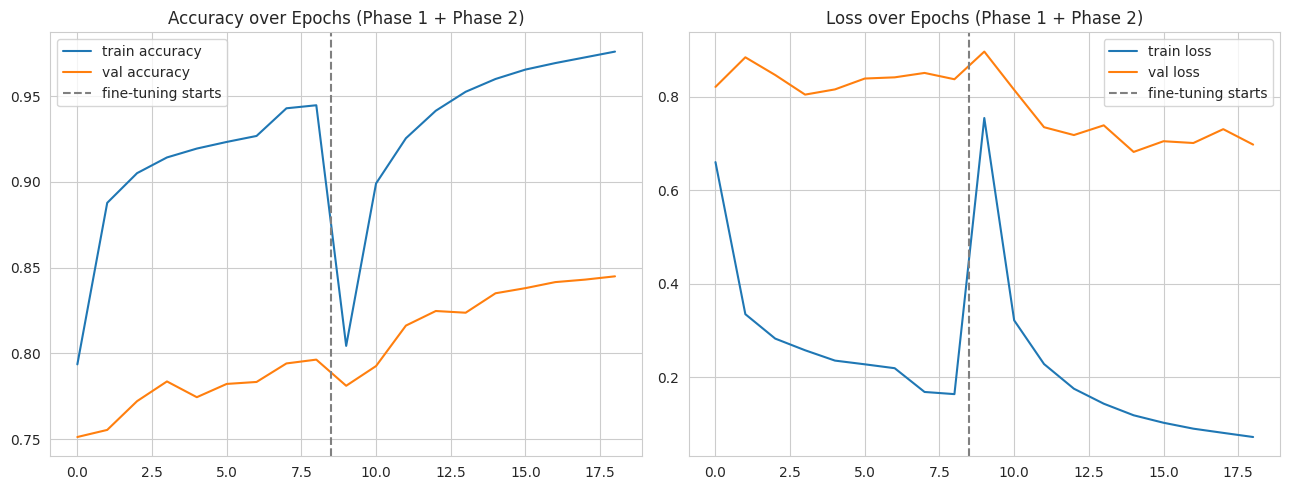

In [ ]:

# ---- Cell 7: combine both phases' history for one continuous plot ----
acc = history_phase1.history["accuracy"] + history_phase2.history["accuracy"]
val_acc = history_phase1.history["val_accuracy"] + history_phase2.history["val_accuracy"]
loss = history_phase1.history["loss"] + history_phase2.history["loss"]
val_loss = history_phase1.history["val_loss"] + history_phase2.history["val_loss"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(acc, label="train accuracy")
axes[0].plot(val_acc, label="val accuracy")
axes[0].axvline(x=len(history_phase1.history["accuracy"]) - 0.5, color="gray", linestyle="--", label="fine-tuning starts")
axes[0].set_title("Accuracy over Epochs (Phase 1 + Phase 2)")
axes[0].legend()

axes[1].plot(loss, label="train loss")
axes[1].plot(val_loss, label="val loss")
axes[1].axvline(x=len(history_phase1.history["loss"]) - 0.5, color="gray", linestyle="--", label="fine-tuning starts")
axes[1].set_title("Loss over Epochs (Phase 1 + Phase 2)")
axes[1].legend()

plt.tight_layout()
plt.savefig("asl_transfer_learning_curves.png", dpi=150)
plt.show()

In [ ]:
# ---- Cell 8: final validation evaluation ----
val_loss_final, val_acc_final = model_asl.evaluate(val_gen, verbose=0)
print(f"Final Validation Loss: {val_loss_final:.4f}")
print(f"Final Validation Accuracy: {val_acc_final:.4f}")


Final Validation Loss: 0.6946
Final Validation Accuracy: 0.8354


In [ ]:
# Save the final model for later use in the webcam demo / dashboard
model_asl.save("asl_final_model.keras")
print("Model saved as asl_final_model.keras")

Model saved as asl_final_model.keras


In [ ]:
from google.colab import files
files.download("asl_final_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>